In [1]:
import importlib
import sys
import os

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

In [ ]:
# Reload the module to pick up new cartographic features
importlib.reload(georef)
from utils.gref_pipeline.georef import *

print(
    "✅ Reloaded georef module with new features: rotation_deg, add_scale_bar, add_north_arrow"
)

In [2]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_125028_1  | shape=(1329, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_125028_2  | shape=(2011, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_125028_3  | shape=(2282, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_125028_4  | shape=(2457, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_125028_5  | shape=(1948, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_125028_1
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)
   • rad_uhi_20241029_125028_2
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
   • rad_uhi_20241029_125028_3
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
   • rad_uhi_20241029_125028_4
  rad_uhi_20241029_125028_4: Using GRIDDED format (T=2457, S=968)
   • rad_uhi_20241029_125028_5
  rad_uhi_20241029_125028_5: Using GRIDDED format (T=1948, S=968)
✅ Combined shapes: X/Y/Z (10027, 968), RGB (

In [ ]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
🔄 Computing illumination correction: rolling (window=500), strength=1.0


   Processing slits:   3%|▎         | 27/968 [00:31<18:18,  1.17s/slit]

In [5]:
%matplotlib qt

💡 Interactive mode: Click on the plot to display coordinates


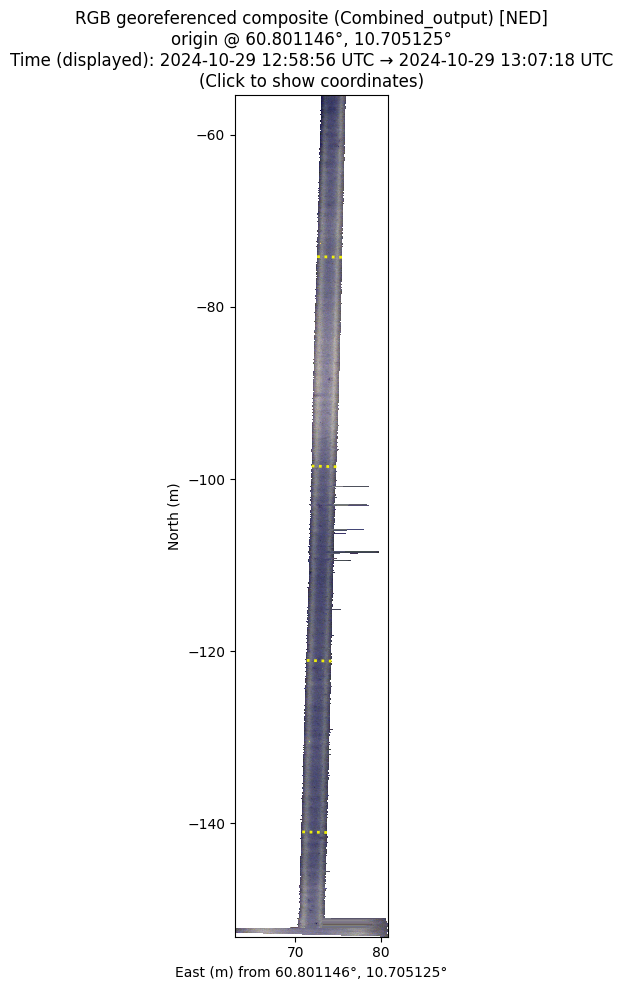

In [4]:
cube.plot_georef(
    use_corrected=False,
    coordinate_system="NED",
    # track_start=config.UHI_TRACK_RANGE_5[0],
    # track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
)

In [6]:
cube.plot_georef(
    use_corrected=False,
    coordinate_system="NED",
    # track_start=config.UHI_TRACK_RANGE_5[0],
    # track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
)

💡 Interactive mode: Click on the plot to display coordinates



📍 track=9983, slit=914
   NED: E=71.47 m, N=-55.36 m
   ECEF: X=3065179.34 m, Y=579528.35 m, Z=5544439.66 m
   WGS84: Lat=60.800649°, Lon=10.706438°, h=-114.58 m
   RGB: R=0.139, G=0.133, B=0.260

📍 track=9983, slit=914
   NED: E=71.47 m, N=-55.36 m
   ECEF: X=3065179.34 m, Y=579528.35 m, Z=5544439.66 m
   WGS84: Lat=60.800649°, Lon=10.706438°, h=-114.58 m
   RGB: R=0.139, G=0.133, B=0.260

📍 track=8831, slit=562
   NED: E=73.95 m, N=-66.73 m
   ECEF: X=3065191.00 m, Y=579533.08 m, Z=5544438.43 m
   WGS84: Lat=60.800547°, Lon=10.706483°, h=-109.63 m
   RGB: R=0.346, G=0.350, B=0.436

📍 track=8427, slit=415
   NED: E=74.30 m, N=-70.75 m
   ECEF: X=3065194.53 m, Y=579534.11 m, Z=5544436.72 m
   WGS84: Lat=60.800511°, Lon=10.706490°, h=-109.34 m
   RGB: R=0.441, G=0.426, B=0.515

📍 track=8020, slit=174
   NED: E=74.98 m, N=-74.80 m
   ECEF: X=3065197.98 m, Y=579535.45 m, Z=5544434.93 m
   WGS84: Lat=60.800475°, Lon=10.706502°, h=-109.13 m
   RGB: R=0.564, G=0.543, B=0.538

📍 track=7468, 

In [ ]:
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
)

# Test New Cartographic Features
Test the new rotation, scale bar, and north arrow features added to `plot_georef()`

In [ ]:
# Test 1: Basic map with scale bar and north arrow (no rotation)
cube.plot_georef(
    use_corrected=False,
    coordinate_system="NED",
    figsize=(15, 12),
    add_scale_bar=True,
    add_north_arrow=True,
)

In [ ]:
# Test 2: Rotated map (30° counter-clockwise) with scale bar and north arrow
cube.plot_georef(
    use_corrected=False,
    coordinate_system="NED",
    figsize=(15, 12),
    rotation_deg=30,
    add_scale_bar=True,
    scale_bar_position="lower right",
    scale_bar_length_m=200,  # Manual 200m scale bar
    add_north_arrow=True,
    north_arrow_position="upper left",
)

In [ ]:
# Test 3: Heavily rotated (-45°) with custom styling
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    figsize=(15, 12),
    rotation_deg=-45,  # Clockwise rotation
    add_scale_bar=True,
    scale_bar_position="upper left",
    scale_bar_color="white",
    scale_bar_fontsize=12,
    add_north_arrow=True,
    north_arrow_position="lower right",
    north_arrow_size=0.1,
    north_arrow_color="red",
)

In [ ]:
# Test 4: Just rotation (keep axes for cropping later)
cube.plot_georef(
    use_corrected=False,
    coordinate_system="NED",
    figsize=(20, 15),
    rotation_deg=15,  # Slight rotation for better alignment
    # Note: No scale bar or north arrow - you can crop axes in post-processing
)